In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import scipy

from astropy.table import Table
import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [2]:
def mass_from_loggteff(loggarray : np.array, teffarray : np.array, 
                       low_model = 'be', mid_model = 'be', high_model = 'be',
                       atm_type = 'H') -> np.array:
    """compute the radial velocity from radius and effective temperature
    """
    mass_sun, radius_sun, newton_G, speed_light = 1.9884e30, 6.957e8, 6.674e-11, 299792458
    font_model = WD_models.load_model(low_model, mid_model, high_model, atm_type) 
    g_acc = (10**font_model['logg'])/100
    rsun = np.sqrt(font_model['mass_array'] * mass_sun * newton_G / g_acc) / radius_sun
    rad_teff_to_mass = WD_models.interp_xy_z_func(x = rsun, y = 10**font_model['logteff'],\
                                                z = font_model['mass_array'], interp_type = 'linear')
    return rad_teff_to_mass(loggarray, teffarray)

In [3]:
data1 = pd.read_csv("../widebinaries/data/merges/apogee_ngf21_merged.csv")
data2 = pd.read_csv("../widebinaries/data/merges/astra_ngf21_merged.csv")
#data3 = pd.read_parquet("../omnidwarf/merges/MWDDDB_widebinaries_astra.pqt").query("fe_h > -999 & flag_bad == False")


#vincent = pd.read_parquet("../../../catalogs/XP-spectra/vincent2024.pqt")
data_apogee = data1.query("FE_H > -999 & ALPHA_M_ERR < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1")
data_astra = data2.query("fe_h > -999 & flag_bad == False & e_alpha_m_atm < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1")
data_galah = pd.read_csv("../widebinaries/data/merges/galah_ngf21_merged.csv").query("e_fe_h < 0.1 & e_Mg_fe < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1")


In [4]:
mm1 = ~data_apogee.wd_source_id.isin(data_astra.wd_source_id)
data_apogee = data_apogee[mm1]

mm2 = np.all([~data_galah.wd_source_id.isin(data_astra.wd_source_id),
              ~data_galah.wd_source_id.isin(data_apogee.wd_source_id)], axis=0)
data_galah = data_galah[mm2]

len(data_galah), len(data_astra)+len(data_apogee)

(18, 260)

In [5]:
list(data_apogee.keys())

['col1',
 'wd_solution_id',
 'ms_solution_id',
 'wd_source_id',
 'ms_source_id',
 'wd_random_index',
 'ms_random_index',
 'wd_ref_epoch',
 'ms_ref_epoch',
 'wd_ra',
 'ms_ra',
 'wd_ra_error',
 'ms_ra_error',
 'wd_dec',
 'ms_dec',
 'wd_dec_error',
 'ms_dec_error',
 'wd_parallax',
 'ms_parallax',
 'wd_parallax_error',
 'ms_parallax_error',
 'wd_parallax_over_error',
 'ms_parallax_over_error',
 'wd_pm',
 'ms_pm',
 'wd_pmra',
 'ms_pmra',
 'wd_pmra_error',
 'ms_pmra_error',
 'wd_pmdec',
 'ms_pmdec',
 'wd_pmdec_error',
 'ms_pmdec_error',
 'wd_ra_dec_corr',
 'ms_ra_dec_corr',
 'wd_ra_parallax_corr',
 'ms_ra_parallax_corr',
 'wd_ra_pmra_corr',
 'ms_ra_pmra_corr',
 'wd_ra_pmdec_corr',
 'ms_ra_pmdec_corr',
 'wd_dec_parallax_corr',
 'ms_dec_parallax_corr',
 'wd_dec_pmra_corr',
 'ms_dec_pmra_corr',
 'wd_dec_pmdec_corr',
 'ms_dec_pmdec_corr',
 'wd_parallax_pmra_corr',
 'ms_parallax_pmra_corr',
 'wd_parallax_pmdec_corr',
 'ms_parallax_pmdec_corr',
 'wd_pmra_pmdec_corr',
 'ms_pmra_pmdec_corr',
 'wd_as

In [6]:
data_apogee["wd_age"] = 10**(data_apogee["log_age"] - 9)
data_apogee["wd_age_lo"] = 10**(data_apogee["log_age_lo"] - 9)
data_apogee["wd_age_hi"] = 10**(data_apogee["log_age_hi"] - 9)

data_apogee["wd_cool_age"] = 10**(data_apogee["log_age_cool"] - 9)
data_apogee["wd_cool_age_lo"] = 10**(data_apogee["log_age_cool_lo"] - 9)
data_apogee["wd_cool_age_hi"] = 10**(data_apogee["log_age_cool_hi"] - 9)


data_astra["wd_age"] = 10**(data_astra["log_age"] - 9)
data_astra["wd_age_lo"] = 10**(data_astra["log_age_lo"] - 9)
data_astra["wd_age_hi"] = 10**(data_astra["log_age_hi"] - 9)

data_astra["wd_cool_age"] = 10**(data_astra["log_age_cool"] - 9)
data_astra["wd_cool_age_lo"] = 10**(data_astra["log_age_cool_lo"] - 9)
data_astra["wd_cool_age_hi"] = 10**(data_astra["log_age_cool_hi"] - 9)


data_galah["wd_age"] = 10**(data_galah["log_age"] - 9)
data_galah["wd_age_lo"] = 10**(data_galah["log_age_lo"] - 9)
data_galah["wd_age_hi"] = 10**(data_galah["log_age_hi"] - 9)

data_galah["wd_cool_age"] = 10**(data_galah["log_age_cool"] - 9)
data_galah["wd_cool_age_lo"] = 10**(data_galah["log_age_cool_lo"] - 9)
data_galah["wd_cool_age_hi"] = 10**(data_galah["log_age_cool_hi"] - 9)

/tmp/ipykernel_88643/674630763.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_astra["wd_age"] = 10**(data_astra["log_age"] - 9)
/tmp/ipykernel_88643/674630763.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_astra["wd_age_lo"] = 10**(data_astra["log_age_lo"] - 9)
/tmp/ipykernel_88643/674630763.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [7]:
data_astra

,col1,wd_solution_id,ms_solution_id,wd_source_id,ms_source_id,wd_random_index,ms_random_index,wd_ref_epoch,ms_ref_epoch,wd_ra,...,v_astra,t_elapsed,t_overhead,tag,wd_age,wd_age_lo,wd_age_hi,wd_cool_age,wd_cool_age_lo,wd_cool_age_hi
0,11,1636042515805110273,1636042515805110273,3050837938914366592,3050837934615434112,1253405058,1462631090,2016.0,2016.0,104.448364,...,8000,NaN,0.0,NaN,3.589238,2.494867,6.610912,2.238721,1.481298,4.075421
2,16,1636042515805110273,1636042515805110273,277090540953615616,277090609673089920,1252129862,653360559,2016.0,2016.0,68.323019,...,8000,NaN,0.0,NaN,NaN,NaN,NaN,0.891251,0.722190,1.087885
3,23,1636042515805110273,1636042515805110273,5544588928434374016,5544588997155925248,962236832,469723743,2016.0,2016.0,121.793368,...,8000,NaN,0.0,NaN,NaN,NaN,NaN,0.150347,0.106017,0.218123
7,120,1636042515805110273,1636042515805110273,472222136549511552,472222209564317568,812275881,1472999000,2016.0,2016.0,66.812587,...,8000,NaN,0.0,NaN,3.335343,2.413660,7.638221,1.979153,1.412538,3.130434
16,231,1636042515805110273,1636042515805110273,2281284871549777536,2281284940269252992,1015128787,1484539912,2016.0,2016.0,345.661370,...,8000,NaN,0.0,NaN,0.965249,0.906446,1.032944,0.600696,0.540651,0.669754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674,7046,1636042515805110273,1636042515805110273,850605735964206720,850605735964206592,866888619,168952610,2016.0,2016.0,159.773861,...,8000,NaN,0.0,NaN,1.249382,1.031649,3.392194,0.551097,0.432127,0.728577
690,7343,1636042515805110273,1636042515805110273,430291749532144128,430268522348053632,973730549,506979359,2016.0,2016.0,8.521900,...,8000,NaN,0.0,NaN,NaN,NaN,NaN,0.893064,0.773538,1.139948
691,7406,1636042515805110273,1636042515805110273,3122495241997802240,3122495237701805696,631181797,418305384,2016.0,2016.0,90.130265,...,8000,NaN,0.0,NaN,NaN,NaN,NaN,0.368824,0.141254,1.134291
692,7409,1636042515805110273,1636042515805110273,936641833642799744,936641902362276736,1499605271,1068268262,2016.0,2016.0,120.380058,...,8000,NaN,0.0,NaN,1.572284,1.446073,1.735710,1.161065,0.988409,1.392194


In [8]:
data_apogee = data_apogee.query("mass_best > 0.63").copy()
mask_apogee = ((-0.1 * data_apogee["FE_H"] + 0.05) < data_apogee["MG_FE"])

data_galah = data_galah.copy()
data_galah = data_galah.query("mass_best > 0.63").copy()
mask_galah = ((-0.1 * data_galah["fe_h"] + 0.05) < data_galah["Mg_fe"])

data_astra = data_astra.copy()
data_astra.loc[:, "mg_fe"] = data_astra["mg_h"] - data_astra["fe_h"]
data_astra.loc[:, "e_mg_fe"] = np.sqrt(data_astra["e_mg_h"]**2 + data_astra["e_fe_h"]**2)
data_astra = data_astra.query("mass_best > 0.63").copy()
mask_astra = ((-0.1 * data_astra["fe_h"] + 0.05) < data_astra["mg_fe"])

age_hi = np.concatenate((
    data_apogee.loc[mask_apogee, ["wd_age", "MG_FE"]].to_numpy(),
    data_astra.loc[mask_astra, ["wd_age", "mg_fe"]].to_numpy(),
    data_galah.loc[mask_galah, ["wd_age", "Mg_fe"]].to_numpy(),
))
e_age_hi  = np.concatenate((
    data_apogee.loc[mask_apogee, ["wd_age_lo", "wd_age_hi", "MG_FE_ERR"]].to_numpy(),
    data_astra.loc[mask_astra, ["wd_age_lo", "wd_age_hi", "e_mg_fe"]].to_numpy(),
    data_galah.loc[mask_galah, ["wd_age_lo", "wd_age_hi", "e_Mg_fe"]].to_numpy(),
))

age_lo = np.concatenate((
    data_apogee.loc[~mask_apogee, ["wd_age", "MG_FE"]].to_numpy(),
    data_astra.loc[~mask_astra, ["wd_age", "mg_fe"]].to_numpy(),
    data_galah.loc[~mask_galah, ["wd_age", "Mg_fe"]].to_numpy(),
))
e_age_lo  = np.concatenate((
    data_apogee.loc[~mask_apogee, ["wd_age_lo", "wd_age_hi", "MG_FE_ERR"]].to_numpy(),
    data_astra.loc[~mask_astra, ["wd_age_lo", "wd_age_hi", "e_mg_fe"]].to_numpy(),
    data_galah.loc[~mask_galah, ["wd_age_lo", "wd_age_hi", "e_Mg_fe"]].to_numpy(),
))

pct_hi = np.percentile(age_hi, [16, 50, 84])
pct_lo = np.percentile(age_lo, [16, 50, 84])

Alpha-enriched stars 1σ consistent with age < 6 Gyr: 6 / 15
Alpha-enriched stars 2σ consistent with age < 6 Gyr: 2 / 15


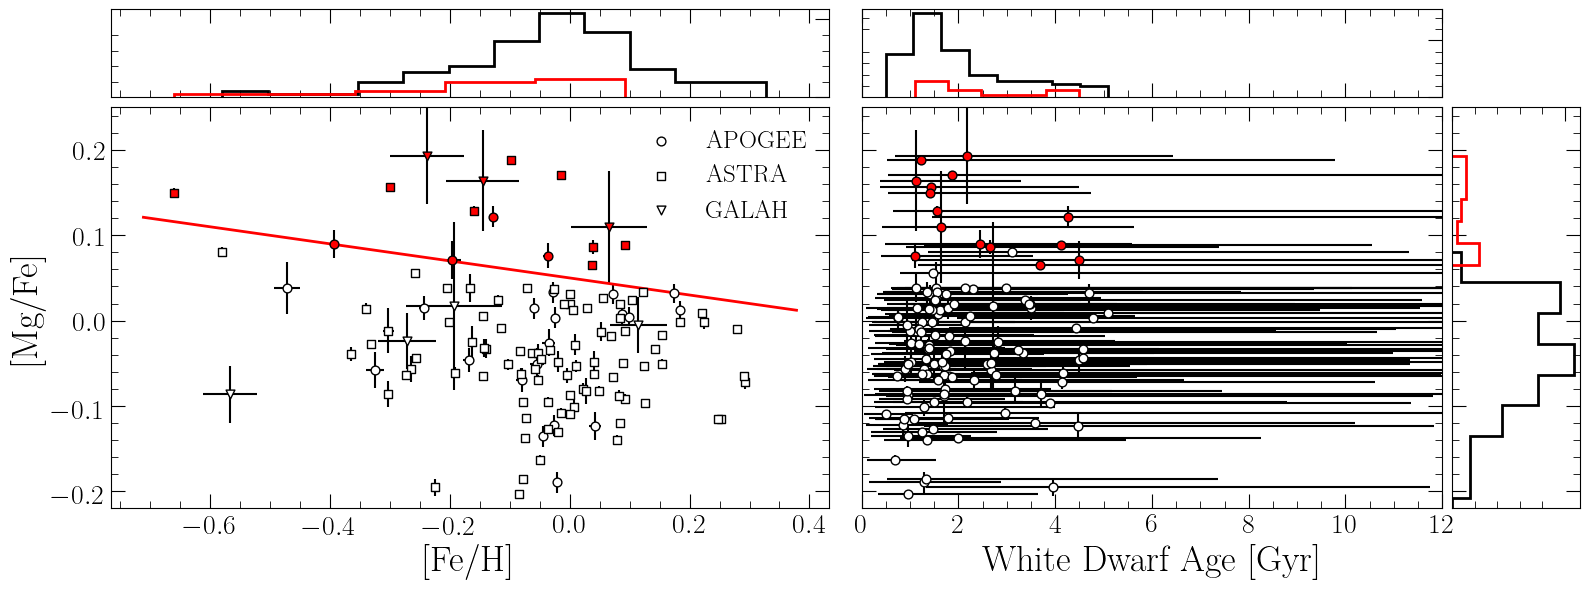

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.stats

fig, ax = plt.subplots(ncols=2, figsize=(16, 6), sharey=True)
# =====================================================
# LEFT PANEL : [Fe/H] vs [Mg/Fe]
# =====================================================

# -------------------------
# APOGEE
# -------------------------
data_apogee = data_apogee.query("mass_best > 0.63").copy()
mask_apogee = ((-0.1 * data_apogee["FE_H"] + 0.05) < data_apogee["MG_FE"])

ax[0].errorbar(
    data_apogee["FE_H"], data_apogee["MG_FE"],
    xerr=data_apogee["FE_H_ERR"], yerr=data_apogee["MG_FE_ERR"],
    c="k", fmt="None", zorder=0
)
ax[0].scatter(
    data_apogee.loc[~mask_apogee, "FE_H"],
    data_apogee.loc[~mask_apogee, "MG_FE"],
    c="white", edgecolor="k", s=40, zorder=1, label="APOGEE"
)
ax[0].scatter(
    data_apogee.loc[mask_apogee, "FE_H"],
    data_apogee.loc[mask_apogee, "MG_FE"],
    c="red", edgecolor="k", s=40, zorder=2
)

# -------------------------
# ASTRA
# -------------------------
data_astra = data_astra.copy()
data_astra["mg_fe"] = data_astra["mg_h"] - data_astra["fe_h"]
data_astra["e_mg_fe"] = np.sqrt(data_astra["e_mg_h"]**2 + data_astra["e_fe_h"]**2)

data_astra = data_astra.query("mass_best > 0.63").copy()
mask_astra = ((-0.1 * data_astra["fe_h"] + 0.05) < data_astra["mg_fe"])

ax[0].errorbar(
    data_astra["fe_h"], data_astra["mg_fe"],
    xerr=data_astra["e_fe_h"], yerr=data_astra["e_mg_fe"],
    c="k", fmt="None", zorder=0
)
ax[0].scatter(
    data_astra.loc[~mask_astra, "fe_h"],
    data_astra.loc[~mask_astra, "mg_fe"],
    c="white", edgecolor="k", marker="s", s=40, zorder=1, label="ASTRA"
)
ax[0].scatter(
    data_astra.loc[mask_astra, "fe_h"],
    data_astra.loc[mask_astra, "mg_fe"],
    c="red", edgecolor="k", marker="s", s=40, zorder=2
)

# -------------------------
# GALAH
# -------------------------
data_galah = data_galah.query("mass_best > 0.63").copy()
mask_galah = ((-0.1 * data_galah["fe_h"] + 0.05) < data_galah["Mg_fe"])

ax[0].errorbar(
    data_galah["fe_h"], data_galah["Mg_fe"],
    xerr=data_galah["e_fe_h"], yerr=data_galah["e_Mg_fe"],
    c="k", fmt="None", zorder=0
)
ax[0].scatter(
    data_galah.loc[~mask_galah, "fe_h"],
    data_galah.loc[~mask_galah, "Mg_fe"],
    c="white", edgecolor="k", marker="v", s=40, zorder=1, label="GALAH"
)
ax[0].scatter(
    data_galah.loc[mask_galah, "fe_h"],
    data_galah.loc[mask_galah, "Mg_fe"],
    c="red", edgecolor="k", marker="v", s=40, zorder=2
)

# -------------------------
# Decision boundary
# -------------------------
#ax[0].set_xlim(-0.7, 0.35)
ax[0].set_ylim(-0.22, 0.25)

xx = np.array(ax[0].get_xlim())
ax[0].plot(xx, -0.1 * xx + 0.05, c="red", lw=2, zorder=0)

ax[0].set_xlabel("[Fe/H]")
ax[0].set_ylabel("[Mg/Fe]")
ax[0].legend(framealpha=0)

# -------------------------
# Top marginal for LEFT panel (x = [Fe/H])
# -------------------------
x_hi_left = np.concatenate([
    data_apogee.loc[mask_apogee, "FE_H"].to_numpy(),
    data_astra.loc[mask_astra, "fe_h"].to_numpy(),
    data_galah.loc[mask_galah, "fe_h"].to_numpy(),
])
x_lo_left = np.concatenate([
    data_apogee.loc[~mask_apogee, "FE_H"].to_numpy(),
    data_astra.loc[~mask_astra, "fe_h"].to_numpy(),
    data_galah.loc[~mask_galah, "fe_h"].to_numpy(),
])

divider0 = make_axes_locatable(ax[0])
ax0_top = divider0.append_axes("top", size="22%", pad=0.10, sharex=ax[0])
ax0_top.hist(x_lo_left, histtype="step", linewidth=2, color="k")
ax0_top.hist(x_hi_left, histtype="step", linewidth=2, color="red")
ax0_top.tick_params(axis="x", labelbottom=False)
ax0_top.tick_params(axis="y", left=False, labelleft=False)
ax0_top.spines["right"].set_visible(True)
ax0_top.spines["top"].set_visible(True)
ax0_top.set_xlim(ax[0].get_xlim())

# =====================================================
# RIGHT PANEL : WD age vs [Mg/Fe] (+ top & right marginals)
# =====================================================

ax[1].errorbar(age_hi[:, 0], age_hi[:, 1],
               xerr=e_age_hi[:, :2].T, yerr=e_age_hi[:, 2],
               fmt="none", c="k", zorder=0)
ax[1].scatter(age_hi[:, 0], age_hi[:, 1],
              c="red", edgecolor="k", s=40, zorder=1)

ax[1].errorbar(age_lo[:, 0], age_lo[:, 1],
               xerr=e_age_lo[:, :2].T, yerr=e_age_lo[:, 2],
               fmt="none", c="k", zorder=0)
ax[1].scatter(age_lo[:, 0], age_lo[:, 1],
              c="white", edgecolor="k", s=40, zorder=1)

ks_equal = scipy.stats.ks_2samp(age_hi[:, 0], age_lo[:, 0],
                               alternative="less", method="asymp")
#ax[1].text(
#    0.95, 0.1,
#    rf"p($\alpha$-Poor Age $\geq$ $\alpha$-Rich Age) = {ks_equal.pvalue:1.2f}",
#    ha="right", va="top", fontsize=18, transform=ax[1].transAxes
#)

ax[1].set_xlabel("White Dwarf Age [Gyr]")
ax[1].set_xlim(0, 12)

# -------------------------
# Top & right marginals for RIGHT panel
#   top: x = age
#   right: y = [Mg/Fe]
# -------------------------
divider1 = make_axes_locatable(ax[1])
ax1_top   = divider1.append_axes("top",   size="22%", pad=0.10, sharex=ax[1])
ax1_right = divider1.append_axes("right", size="22%", pad=0.10, sharey=ax[1])

# top histogram (age)
ax1_top.hist(age_lo[:, 0], histtype="step", linewidth=2, color="k")
ax1_top.hist(age_hi[:, 0],  histtype="step", linewidth=2, color="red")
ax1_top.tick_params(axis="x", labelbottom=False)
ax1_top.tick_params(axis="y", left=False, labelleft=False)
ax1_top.spines["right"].set_visible(True)
ax1_top.spines["top"].set_visible(True)
ax1_top.set_xlim(ax[1].get_xlim())

# right histogram (Mg/Fe) as horizontal hist
ax1_right.hist(age_lo[:, 1], histtype="step", linewidth=2, color="k",
               orientation="horizontal")
ax1_right.hist(age_hi[:, 1], histtype="step", linewidth=2, color="red",
               orientation="horizontal")
ax1_right.tick_params(axis="y", labelleft=False)
ax1_right.tick_params(axis="x", bottom=False, labelbottom=False)
ax1_right.spines["right"].set_visible(True)
ax1_right.spines["top"].set_visible(True)
ax1_right.set_ylim(ax[1].get_ylim())

# Replace fig.tight_layout() with manual spacing
fig.tight_layout()
fig.savefig("figures/metallicity_age.pdf")

# e_age_hi[:, 0] = lower age error, e_age_hi[:, 1] = upper age error
lower_bound = age_hi[:, 0] + e_age_hi[:, 1]
consistent_with_young = np.sum(lower_bound < 6)
print(f"Alpha-enriched stars 1σ consistent with age < 6 Gyr: {consistent_with_young} / {len(age_hi)}")

lower_bound = age_hi[:, 0] + 2*e_age_hi[:, 1]
consistent_with_young = np.sum(lower_bound < 6)
print(f"Alpha-enriched stars 2σ consistent with age < 6 Gyr: {consistent_with_young} / {len(age_hi)}")

(-0.7, 0.35)

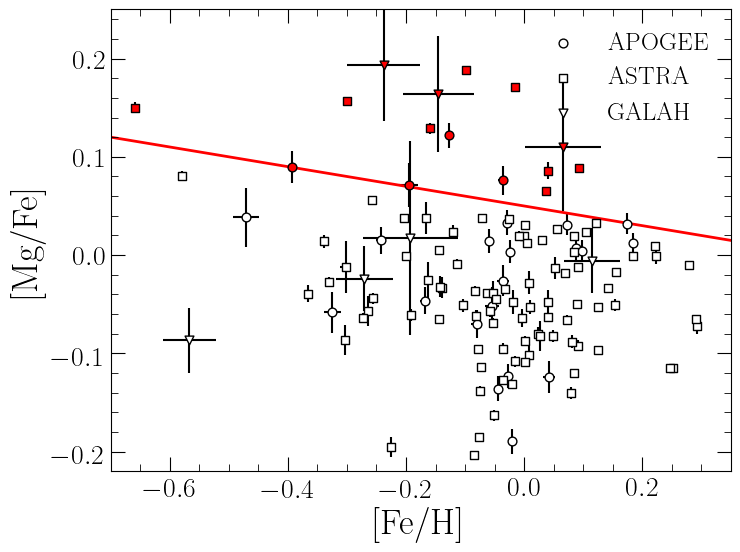

In [14]:
fig, ax = plt.subplots( figsize=(8, 6))
# =====================================================
# LEFT PANEL : [Fe/H] vs [Mg/Fe]
# =====================================================

# -------------------------
# APOGEE
# -------------------------
data_apogee = data_apogee.query("mass_best > 0.63").copy()
mask_apogee = ((-0.1 * data_apogee["FE_H"] + 0.05) < data_apogee["MG_FE"])

ax.errorbar(
    data_apogee["FE_H"], data_apogee["MG_FE"],
    xerr=data_apogee["FE_H_ERR"], yerr=data_apogee["MG_FE_ERR"],
    c="k", fmt="None", zorder=0
)
ax.scatter(
    data_apogee.loc[~mask_apogee, "FE_H"],
    data_apogee.loc[~mask_apogee, "MG_FE"],
    c="white", edgecolor="k", s=40, zorder=1, label="APOGEE"
)
ax.scatter(
    data_apogee.loc[mask_apogee, "FE_H"],
    data_apogee.loc[mask_apogee, "MG_FE"],
    c="red", edgecolor="k", s=40, zorder=2
)

# -------------------------
# ASTRA
# -------------------------
data_astra = data_astra.copy()
data_astra["mg_fe"] = data_astra["mg_h"] - data_astra["fe_h"]
data_astra["e_mg_fe"] = np.sqrt(data_astra["e_mg_h"]**2 + data_astra["e_fe_h"]**2)

data_astra = data_astra.query("mass_best > 0.63").copy()
mask_astra = ((-0.1 * data_astra["fe_h"] + 0.05) < data_astra["mg_fe"])

ax.errorbar(
    data_astra["fe_h"], data_astra["mg_fe"],
    xerr=data_astra["e_fe_h"], yerr=data_astra["e_mg_fe"],
    c="k", fmt="None", zorder=0
)
ax.scatter(
    data_astra.loc[~mask_astra, "fe_h"],
    data_astra.loc[~mask_astra, "mg_fe"],
    c="white", edgecolor="k", marker="s", s=40, zorder=1, label="ASTRA"
)
ax.scatter(
    data_astra.loc[mask_astra, "fe_h"],
    data_astra.loc[mask_astra, "mg_fe"],
    c="red", edgecolor="k", marker="s", s=40, zorder=2
)

# -------------------------
# GALAH
# -------------------------
data_galah = data_galah.query("mass_best > 0.63").copy()
mask_galah = ((-0.1 * data_galah["fe_h"] + 0.05) < data_galah["Mg_fe"])

ax.errorbar(
    data_galah["fe_h"], data_galah["Mg_fe"],
    xerr=data_galah["e_fe_h"], yerr=data_galah["e_Mg_fe"],
    c="k", fmt="None", zorder=0
)
ax.scatter(
    data_galah.loc[~mask_galah, "fe_h"],
    data_galah.loc[~mask_galah, "Mg_fe"],
    c="white", edgecolor="k", marker="v", s=40, zorder=1, label="GALAH"
)
ax.scatter(
    data_galah.loc[mask_galah, "fe_h"],
    data_galah.loc[mask_galah, "Mg_fe"],
    c="red", edgecolor="k", marker="v", s=40, zorder=2
)

# -------------------------
# Decision boundary
# -------------------------
#ax[0].set_xlim(-0.7, 0.35)
ax.set_ylim(-0.22, 0.25)

xx = np.array(ax.get_xlim())
ax.plot(xx, -0.1 * xx + 0.05, c="red", lw=2, zorder=0)

ax.set_xlabel("[Fe/H]")
ax.set_ylabel("[Mg/Fe]")
ax.legend(framealpha=0)
ax.set_xlim(-0.7, 0.35)

In [ ]:
tars_astra = pd.read_csv("../widebinaries/data/merges/astra_tars_merged.csv").query("fe_h > -999 & flag_bad == False & e_alpha_m_atm < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1")
tars_astra["mg_fe"] = tars_astra["mg_h"] - tars_astra["fe_h"]
tars_astra["e_mg_fe"] = np.sqrt(tars_astra["e_mg_h"]**2 + tars_astra["e_fe_h"]**2)

tars_galah = pd.read_csv("../widebinaries/data/merges/galah_tars_merged.csv").query("e_fe_h < 0.1 & e_Mg_fe < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1")
tars_apogee = pd.read_csv("../widebinaries/data/merges/apogee_tars_merged.csv").query("FE_H > -999 & ALPHA_M_ERR < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1")

galah_ids_hi, galah_ids_low = data_galah.loc[mask_galah, "wd_source_id"], data_galah.loc[~mask_galah, "wd_source_id"]
apogee_ids_hi, apogee_ids_low = data_apogee.loc[mask_apogee, "wd_source_id"], data_apogee.loc[~mask_apogee, "wd_source_id"]
astra_ids_hi, astra_ids_low = data_astra.loc[mask_astra, "wd_source_id"], data_astra.loc[~mask_astra, "wd_source_id"]


In [ ]:
tars_apogee["wd_age"] = 10**(tars_apogee["log_age"] - 9)
tars_apogee["wd_age_lo"] = 10**(tars_apogee["log_age_lo"] - 9)
tars_apogee["wd_age_hi"] = 10**(tars_apogee["log_age_hi"] - 9)

tars_astra["wd_age"] = 10**(tars_astra["log_age"] - 9)
tars_astra["wd_age_lo"] = 10**(tars_astra["log_age_lo"] - 9)
tars_astra["wd_age_hi"] = 10**(tars_astra["log_age_hi"] - 9)

tars_galah["wd_age"] = 10**(tars_galah["log_age"] - 9)
tars_galah["wd_age_lo"] = 10**(tars_galah["log_age_lo"] - 9)
tars_galah["wd_age_hi"] = 10**(tars_galah["log_age_hi"] - 9)

In [ ]:
tars_galah_hi = tars_galah[tars_galah.wd_source_id.isin(galah_ids_hi)]
tars_galah_low = tars_galah[tars_galah.wd_source_id.isin(galah_ids_low)]

tars_apogee_hi = tars_apogee[tars_apogee.wd_source_id.isin(apogee_ids_hi)]
tars_apogee_low = tars_apogee[tars_apogee.wd_source_id.isin(apogee_ids_low)]

tars_astra_hi = tars_astra[tars_astra.wd_source_id.isin(astra_ids_hi)]
tars_astra_low = tars_astra[tars_astra.wd_source_id.isin(astra_ids_low)]

In [ ]:
tars_hi = np.concatenate((
    tars_apogee_hi.loc[:, ["wd_age", "adopted_period"]].to_numpy(),
    tars_astra_hi.loc[:, ["wd_age", "adopted_period"]].to_numpy(),
    tars_galah_hi.loc[:, ["wd_age", "adopted_period"]].to_numpy(),
))
e_tars_hi  = np.concatenate((
    tars_apogee_hi.loc[:, ["wd_age_lo", "wd_age_hi", "adopted_period_unc"]].to_numpy(),
    tars_astra_hi.loc[:, ["wd_age_lo", "wd_age_hi", "adopted_period_unc"]].to_numpy(),
    tars_galah_hi.loc[:, ["wd_age_lo", "wd_age_hi", "adopted_period_unc"]].to_numpy(),
))

tars_lo = np.concatenate((
    tars_apogee_low.loc[:, ["wd_age", "adopted_period"]].to_numpy(),
    tars_astra_low.loc[:, ["wd_age", "adopted_period"]].to_numpy(),
    tars_galah_low.loc[:, ["wd_age", "adopted_period"]].to_numpy(),
))
e_tars_lo  = np.concatenate((
    tars_apogee_low.loc[:, ["wd_age_lo", "wd_age_hi", "adopted_period_unc"]].to_numpy(),
    tars_astra_low.loc[:, ["wd_age_lo", "wd_age_hi", "adopted_period_unc"]].to_numpy(),
    tars_galah_low.loc[:, ["wd_age_lo", "wd_age_hi", "adopted_period_unc"]].to_numpy(),
))

(0.0, 12.0)

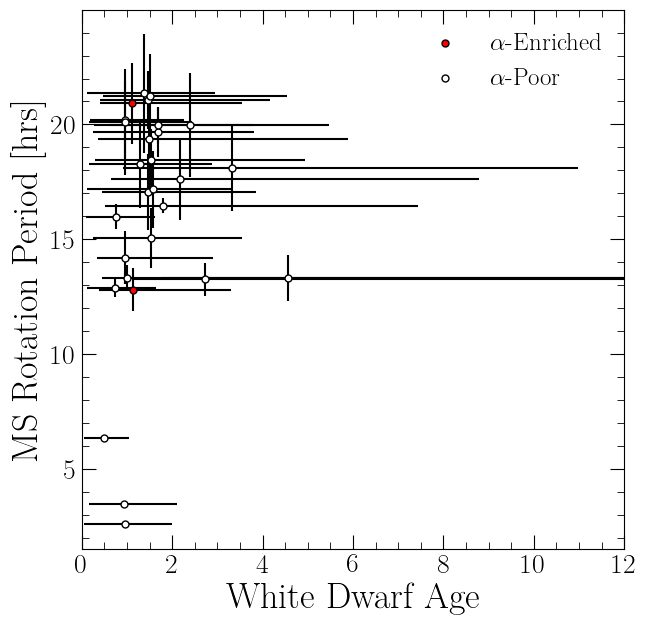

In [ ]:
plt.scatter(tars_hi[:,0], tars_hi[:,1], c="red", edgecolor="k", zorder=1, label=r"$\alpha$-Enriched")
plt.errorbar(tars_hi[:,0], tars_hi[:,1], xerr=e_tars_hi[:,:2].T, yerr=e_tars_hi[:,2], fmt="none", c="k", zorder=0)

plt.scatter(tars_lo[:,0], tars_lo[:,1], c="white", edgecolor="k", zorder=1, label=r"$\alpha$-Poor")
plt.errorbar(tars_lo[:,0], tars_lo[:,1], xerr=e_tars_lo[:,:2].T, yerr=e_tars_lo[:,2], fmt="none", c="k", zorder=0)

plt.xlabel("White Dwarf Age")
plt.ylabel("MS Rotation Period [hrs]")
plt.legend(framealpha=0)
plt.xlim(0, 12)

(-0.7106468985, 0.37835306850000006)

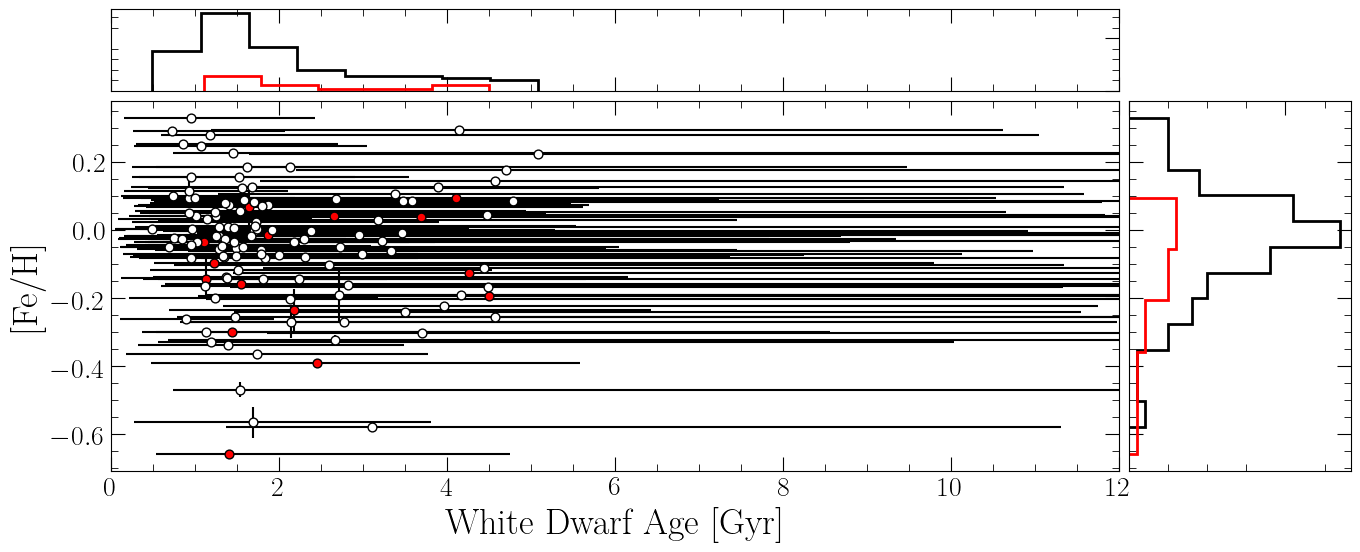

In [ ]:
fig, ax = plt.subplots(ncols=1, figsize=(16, 6), sharey=True)

age_hi = np.concatenate((
    data_apogee.loc[mask_apogee, ["wd_age", "FE_H"]].to_numpy(),
    data_astra.loc[mask_astra, ["wd_age", "fe_h"]].to_numpy(),
    data_galah.loc[mask_galah, ["wd_age", "fe_h"]].to_numpy(),
))
e_age_hi  = np.concatenate((
    data_apogee.loc[mask_apogee, ["wd_age_lo", "wd_age_hi", "FE_H_ERR"]].to_numpy(),
    data_astra.loc[mask_astra, ["wd_age_lo", "wd_age_hi", "e_fe_h"]].to_numpy(),
    data_galah.loc[mask_galah, ["wd_age_lo", "wd_age_hi", "e_fe_h"]].to_numpy(),
))

age_lo = np.concatenate((
    data_apogee.loc[~mask_apogee, ["wd_age", "FE_H"]].to_numpy(),
    data_astra.loc[~mask_astra, ["wd_age", "fe_h"]].to_numpy(),
    data_galah.loc[~mask_galah, ["wd_age", "fe_h"]].to_numpy(),
))
e_age_lo  = np.concatenate((
    data_apogee.loc[~mask_apogee, ["wd_age_lo", "wd_age_hi", "FE_H_ERR"]].to_numpy(),
    data_astra.loc[~mask_astra, ["wd_age_lo", "wd_age_hi", "e_fe_h"]].to_numpy(),
    data_galah.loc[~mask_galah, ["wd_age_lo", "wd_age_hi", "e_fe_h"]].to_numpy(),
))

# -------------------------
# Top marginal for LEFT panel (x = [Fe/H])
# -------------------------
x_hi_left = np.concatenate([
    data_apogee.loc[mask_apogee, "FE_H"].to_numpy(),
    data_astra.loc[mask_astra, "fe_h"].to_numpy(),
    data_galah.loc[mask_galah, "fe_h"].to_numpy(),
])
x_lo_left = np.concatenate([
    data_apogee.loc[~mask_apogee, "FE_H"].to_numpy(),
    data_astra.loc[~mask_astra, "fe_h"].to_numpy(),
    data_galah.loc[~mask_galah, "fe_h"].to_numpy(),
])


# =====================================================
# RIGHT PANEL : WD age vs [Mg/Fe] (+ top & right marginals)
# =====================================================

ax.errorbar(age_hi[:, 0], age_hi[:, 1],
               xerr=e_age_hi[:, :2].T, yerr=e_age_hi[:, 2],
               fmt="none", c="k", zorder=0)
ax.scatter(age_hi[:, 0], age_hi[:, 1],
              c="red", edgecolor="k", s=40, zorder=1)

ax.errorbar(age_lo[:, 0], age_lo[:, 1],
               xerr=e_age_lo[:, :2].T, yerr=e_age_lo[:, 2],
               fmt="none", c="k", zorder=0)
ax.scatter(age_lo[:, 0], age_lo[:, 1],
              c="white", edgecolor="k", s=40, zorder=1)

ks_equal = scipy.stats.ks_2samp(age_hi[:, 0], age_lo[:, 0],
                               alternative="less", method="asymp")
#ax[1].text(
#    0.95, 0.1,
#    rf"p($\alpha$-Poor Age $\geq$ $\alpha$-Rich Age) = {ks_equal.pvalue:1.2f}",
#    ha="right", va="top", fontsize=18, transform=ax[1].transAxes
#)

ax.set_xlabel("White Dwarf Age [Gyr]")
ax.set_ylabel("[Fe/H]")
ax.set_xlim(0, 12)

# -------------------------
# Top & right marginals for RIGHT panel
#   top: x = age
#   right: y = [Mg/Fe]
# -------------------------
divider1 = make_axes_locatable(ax)
ax1_top   = divider1.append_axes("top",   size="22%", pad=0.10, sharex=ax)
ax1_right = divider1.append_axes("right", size="22%", pad=0.10, sharey=ax)

# top histogram (age)
ax1_top.hist(age_lo[:, 0], histtype="step", linewidth=2, color="k")
ax1_top.hist(age_hi[:, 0],  histtype="step", linewidth=2, color="red")
ax1_top.tick_params(axis="x", labelbottom=False)
ax1_top.tick_params(axis="y", left=False, labelleft=False)
ax1_top.spines["right"].set_visible(True)
ax1_top.spines["top"].set_visible(True)
ax1_top.set_xlim(ax.get_xlim())

# right histogram (Mg/Fe) as horizontal hist
ax1_right.hist(age_lo[:, 1], histtype="step", linewidth=2, color="k",
               orientation="horizontal")
ax1_right.hist(age_hi[:, 1], histtype="step", linewidth=2, color="red",
               orientation="horizontal")
ax1_right.tick_params(axis="y", labelleft=False)
ax1_right.tick_params(axis="x", bottom=False, labelbottom=False)
ax1_right.spines["right"].set_visible(True)
ax1_right.spines["top"].set_visible(True)
ax1_right.set_ylim(ax.get_ylim())